# 특정 게임 출시 후 LLM 리뷰 감성분석 보고서

## 목적

- 이 게임은 출시 후 왜 반응이 좋거나 나쁜가?  
- 부정 리뷰에서 반복되는 문제는 무엇인가?  
- 개발자는 무엇을 먼저 패치하거나 운영에서 대응해야 하는가?

## 사용 데이터

기본적으로 아래 파일을 사용합니다.

| 파일 | 역할 |
|---|---|
| `steam_review_llm_results.csv` | 리뷰 단위 LLM 감성분석 결과 |
| `llm_issue_tags_flat.csv` | 리뷰별 이슈 태그를 행 단위로 펼친 데이터 |

선택적으로 아래 파일이 있으면 참고용으로만 사용할 수 있습니다.

| 파일 | 역할 |
|---|---|
| `llm_game_summary.csv` | 게임 단위 요약 |
| `llm_issue_priority_summary.csv` | 전체 이슈 요약 |
| `llm_operation_priority.csv` | 여러 게임 비교용 운영 우선순위 |

이 노트북은 **출시 후 특정 게임 진단용**이므로, 여러 게임 비교용 파일보다는 리뷰 단위 결과와 태그 단위 결과를 중심으로 사용합니다.


In [1]:
# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import platform
import ast
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


# ============================================================
# 1. 파일 경로 설정
# ============================================================

ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")
RUN_NAME = "main_action_d0_d30"

OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

GAME_SUMMARY_PATH = OUTPUT_DIR / "llm_game_summary.csv"
ISSUE_PRIORITY_PATH = OUTPUT_DIR / "llm_issue_priority_summary.csv"
OPERATION_PRIORITY_PATH = OUTPUT_DIR / "llm_operation_priority.csv"

# 1. 설정값

아래 설정값만 바꾸면 다른 게임에도 같은 보고서 구조를 적용할 수 있습니다.

현재 업로드된 테스트 데이터처럼 여러 게임이 섞여 있을 경우, `TARGET_APPID` 또는 `TARGET_GAME_NAME`을 지정하면 해당 게임만 필터링합니다.

둘 다 비워두면 리뷰 수가 가장 많은 게임 1개를 자동 선택합니다.


In [2]:
# ============================================================
# 1. 설정값
# ============================================================

# 필수 입력 파일
RESULT_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
TAG_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"

# 선택 입력 파일
GAME_SUMMARY_PATH = OUTPUT_DIR / "llm_game_summary.csv"
ISSUE_PRIORITY_PATH = OUTPUT_DIR / "llm_issue_priority_summary.csv"
OPERATION_PRIORITY_PATH = OUTPUT_DIR / "llm_operation_priority.csv"

# ------------------------------------------------------------
# 분석 대상 게임 설정
# ------------------------------------------------------------
# 둘 중 하나만 지정하면 됩니다.
# 예시:
# TARGET_APPID = 1443620
# TARGET_GAME_NAME = "Pirates VR: Jolly Roger"

TARGET_APPID = None
TARGET_GAME_NAME = None

# TARGET_APPID/TARGET_GAME_NAME이 모두 비어 있고 여러 게임이 있으면,
# 리뷰 수가 가장 많은 게임을 자동 선택합니다.
AUTO_SELECT_IF_MULTIPLE_GAMES = True

# 보고서에서 보여줄 상위 이슈 개수
TOP_N_ISSUES = 7

# 플레이타임 구간 기준
# 0~1시간: 첫인상/초기 이탈
# 1~5시간: 초반 플레이 경험
# 5시간 이상: 누적 플레이/유지 경험
PLAYTIME_BINS = [-0.001, 1, 5, np.inf]
PLAYTIME_LABELS = ["0~1시간", "1~5시간", "5시간 이상"]

print("설정값 준비 완료")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RESULT_PATH:", RESULT_PATH)
print("TAG_PATH:", TAG_PATH)


설정값 준비 완료
OUTPUT_DIR: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0_d30
RESULT_PATH: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0_d30\llm_review_analysis_result.csv
TAG_PATH: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0_d30\llm_issue_tags_flat.csv


# 2. 데이터 불러오기 및 기본 점검

출시 후 분석에서는 리뷰 단위 데이터와 이슈 태그 단위 데이터가 핵심입니다.

- 리뷰 단위 데이터: 리뷰별 감정, 긴급도, 플레이타임, 출시 후 경과일 확인
- 태그 단위 데이터: 부정 이슈가 어떤 유형으로 반복되는지 확인


In [3]:
# ============================================================
# 2. 데이터 불러오기 및 기본 점검
# ============================================================

df_result_raw = pd.read_csv(RESULT_PATH)
df_tags_raw = pd.read_csv(TAG_PATH)

print("df_result_raw shape:", df_result_raw.shape)
print("df_tags_raw shape:", df_tags_raw.shape)

display(df_result_raw.head(3))
display(df_tags_raw.head(3))

df_result_raw shape: (206, 19)
df_tags_raw shape: (676, 15)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,194594148,1054510,Survivalist: Invisible Strain,2025-05-10 09:22:51,2025-04-25,15.0,D8-D30,negative,0.516667,1,0.458714,negative,difficulty,"[{'category': 'difficulty', 'sentiment': 'negative', 'evidence': 'absolutely hard to get into it, no clue about what...",high,"리뷰어는 게임의 그래픽 스타일은 개인적인 취향 문제로 평가하지 않지만, 게임에 진입하기가 매우 어렵다고 느꼈습니다. 튜토리얼이 전혀 없어 무엇을 해야 할지 몰랐고, '스토리 모드'조차 기본적인 게임 플레이를 ...","신규 플레이어가 게임의 핵심 메커니즘, 조작법, 초기 목표를 이해할 수 있도록 포괄적인 기본 튜토리얼을 구현해야 합니다. 특히 '스토리 모드'가 튜토리얼 역할을 제대로 수행하도록 개선해야 합니다.",exact_match
1,success,193616549,1054510,Survivalist: Invisible Strain,2025-04-26 10:09:11,2025-04-25,1.0,D0-D7,negative,1.000000,79,0.680132,negative,gameplay_loop,"[{'category': 'control', 'sentiment': 'negative', 'evidence': 'movement and combat is just too clunky, Why can I not...",high,"리뷰어는 게임의 움직임과 전투가 너무 투박하고, 인벤토리 관리가 형편없으며, 은신 메커니즘이 비효율적이라고 비판했습니다. 경제 시스템도 불균형하며, 아이템을 파괴만 할 수 있고 버릴 수 없는 등 여러 '이상한...","움직임/전투 조작감 개선(달리기 토글 등), 인벤토리 관리 시스템 개편, 경제 밸런스 조정(판매/구매 가격), 은신 메커니즘 개선, 아이템 드롭 옵션 추가, 핵심 디자인 재평가.",exact_match
2,success,194842979,1054510,Survivalist: Invisible Strain,2025-05-13 21:12:23,2025-04-25,18.0,D8-D30,positive,71.333333,1,0.500000,positive,positive_praise,"[{'category': 'difficulty', 'sentiment': 'mixed', 'evidence': 'didn\'t know what I was doing, Story mode is probably...",low,"초기 플레이 시 어려움을 겪었으나, 스토리 모드를 통해 게임을 익힌 후 즐겁게 플레이 중. State of Decay, Rimworld, Kenshi와 유사하며, 개발사의 지속적인 업데이트(특히 체력 감소 완...",현재와 같이 품질 개선 및 밸런스 조정 업데이트를 지속적으로 제공하여 장기 플레이어들의 만족도를 유지해야 합니다. '스토리 모드'가 신규 플레이어에게 더 접근하기 쉬운 튜토리얼이 될 수 있도록 선택적 힌트나 ...,exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,194594148,1054510,Survivalist: Invisible Strain,negative,negative,difficulty,high,D8-D30,0.516667,1,0.458714,difficulty,난이도,negative,"absolutely hard to get into it, no clue about whatsoever, game just throws you in, no idea of what to do"
1,194594148,1054510,Survivalist: Invisible Strain,negative,negative,difficulty,high,D8-D30,0.516667,1,0.458714,ui_ux,UI/UX,negative,This game has nothin' [tutorial]
2,193616549,1054510,Survivalist: Invisible Strain,negative,negative,gameplay_loop,high,D0-D7,1.000000,79,0.680132,control,조작감,negative,"movement and combat is just too clunky, Why can I not press shift again to stop running"


In [4]:
# ============================================================
# 2-1. 컬럼 표준화 및 파생 컬럼 생성
# ============================================================

df_result = df_result_raw.copy()
df_tags = df_tags_raw.copy()

# 날짜형 변환
if "review_datetime" in df_result.columns:
    df_result["review_datetime"] = pd.to_datetime(df_result["review_datetime"], errors="coerce")

if "release_date" in df_result.columns:
    df_result["release_date"] = pd.to_datetime(df_result["release_date"], errors="coerce")

# days_from_release가 없거나 비어 있으면 날짜 차이로 생성
if "days_from_release" not in df_result.columns or df_result["days_from_release"].isna().all():
    if {"review_datetime", "release_date"}.issubset(df_result.columns):
        df_result["days_from_release"] = (df_result["review_datetime"] - df_result["release_date"]).dt.days

# release_period가 없으면 생성
if "release_period" not in df_result.columns:
    df_result["release_period"] = pd.cut(
        df_result["days_from_release"],
        bins=[-1, 7, 30, 90, np.inf],
        labels=["D0-D7", "D8-D30", "D31-D90", "D91+"]
    ).astype("object")

# 플레이타임 구간 생성
if "playtime_at_review_hours" in df_result.columns:
    df_result["playtime_bin"] = pd.cut(
        df_result["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_result["playtime_bin"] = "정보 없음"

# Steam 긍정/부정 라벨 보정
if "steam_label_text" not in df_result.columns and "steam_voted_up" in df_result.columns:
    df_result["steam_label_text"] = np.where(df_result["steam_voted_up"], "positive", "negative")

# LLM 결과가 없는 경우를 대비한 안전 처리
for col in ["llm_sentiment", "urgency", "primary_issue", "summary", "suggested_action"]:
    if col not in df_result.columns:
        df_result[col] = np.nan

# recommendationid 타입 통일
if "recommendationid" in df_result.columns:
    df_result["recommendationid"] = df_result["recommendationid"].astype(str)
if "recommendationid" in df_tags.columns:
    df_tags["recommendationid"] = df_tags["recommendationid"].astype(str)

# ------------------------------------------------------------
# issue_tags 기준 태그 데이터 재생성
# ------------------------------------------------------------
def parse_issue_tags(value):
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
        except Exception:
            try:
                parsed = json.loads(value)
            except Exception:
                return []

        if isinstance(parsed, list):
            return parsed

    return []

def make_tag_rows_from_result(df):
    tag_rows = []

    meta_cols = [
        "recommendationid", "appid", "game_name", "steam_label_text",
        "llm_sentiment", "primary_issue", "urgency", "release_period",
        "genres_text", "top_steam_tags_text", "review_datetime", "release_date",
        "days_from_release", "playtime_at_review_hours", "playtime_bin",
        "playtime_stage", "votes_up", "weighted_vote_score", "suggested_action"
    ]
    meta_cols = [c for c in meta_cols if c in df.columns]

    for _, row in df.iterrows():
        tags = parse_issue_tags(row.get("issue_tags", []))

        for tag in tags:
            if not isinstance(tag, dict):
                continue

            record = {c: row.get(c) for c in meta_cols}
            record.update({
                "tag_category": tag.get("category"),
                "tag_sentiment": tag.get("sentiment"),
                "tag_evidence": tag.get("evidence")
            })
            tag_rows.append(record)

    return pd.DataFrame(tag_rows)

df_tags_from_result = make_tag_rows_from_result(df_result)

if not df_tags_from_result.empty:
    df_tags = df_tags_from_result.copy()

# 태그 데이터에 플레이타임/투표수/날짜 정보가 없을 수 있으므로 리뷰 데이터에서 병합
merge_cols = [
    "recommendationid", "appid", "game_name", "review_datetime", "release_date",
    "days_from_release", "playtime_at_review_hours", "playtime_bin",
    "votes_up", "weighted_vote_score", "steam_label_text",
    "llm_sentiment", "urgency", "suggested_action"
]
merge_cols = [c for c in merge_cols if c in df_result.columns]

# df_tags에 이미 있는 컬럼과 충돌하지 않도록 필요한 컬럼만 추가
if not df_tags.empty and "recommendationid" in df_tags.columns:
    extra_cols = [c for c in merge_cols if c not in df_tags.columns or c == "recommendationid"]
    df_tags = df_tags.merge(
        df_result[extra_cols].drop_duplicates("recommendationid"),
        on="recommendationid",
        how="left"
    )

print("전처리 후 df_result shape:", df_result.shape)
print("전처리 후 df_tags shape:", df_tags.shape)

전처리 후 df_result shape: (206, 20)
전처리 후 df_tags shape: (676, 19)


# 3. 분석 대상 게임 선택

실제 출시 후 분석에서는 특정 게임 1개만 들어오는 것이 가장 좋습니다.

다만 현재 테스트 파일처럼 여러 게임이 섞여 있을 수 있으므로, 아래 코드에서 대상 게임을 자동 선택하거나 직접 지정할 수 있게 했습니다.


본격적인 작업 시작할땐 수정할 예정

In [5]:
# ============================================================
# 3. 분석 대상 게임 선택
# ============================================================

game_counts = (
    df_result
    .groupby(["appid", "game_name"], dropna=False)
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

display(Markdown("## 현재 데이터에 포함된 게임 목록"))
display(game_counts)

if TARGET_APPID is not None:
    df_game = df_result[df_result["appid"] == TARGET_APPID].copy()
    selected_reason = f"TARGET_APPID={TARGET_APPID} 기준 선택"
elif TARGET_GAME_NAME is not None:
    df_game = df_result[df_result["game_name"] == TARGET_GAME_NAME].copy()
    selected_reason = f"TARGET_GAME_NAME={TARGET_GAME_NAME} 기준 선택"
else:
    if df_result["appid"].nunique() == 1:
        selected_appid = df_result["appid"].iloc[0]
        df_game = df_result.copy()
        selected_reason = "데이터에 게임이 1개만 있어 자동 선택"
    elif AUTO_SELECT_IF_MULTIPLE_GAMES:
        selected_appid = game_counts.iloc[0]["appid"]
        selected_name = game_counts.iloc[0]["game_name"]
        df_game = df_result[df_result["appid"] == selected_appid].copy()
        selected_reason = f"여러 게임 중 리뷰 수가 가장 많은 게임 자동 선택: {selected_name}"
    else:
        raise ValueError("여러 게임이 있습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 지정해 주세요.")

if df_game.empty:
    raise ValueError("선택된 게임 데이터가 없습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 확인해 주세요.")

selected_appid = df_game["appid"].iloc[0] if "appid" in df_game.columns else None
selected_game_name = df_game["game_name"].iloc[0] if "game_name" in df_game.columns else "선택된 게임"

# 태그 데이터도 같은 게임으로 필터링
if selected_appid is not None and "appid" in df_tags.columns:
    df_game_tags = df_tags[df_tags["appid"] == selected_appid].copy()
elif "game_name" in df_tags.columns:
    df_game_tags = df_tags[df_tags["game_name"] == selected_game_name].copy()
else:
    df_game_tags = df_tags.copy()

display(Markdown(f"""
## 분석 대상 게임

- 선택 기준: `{selected_reason}`
- 게임명: **{selected_game_name}**
- appid: `{selected_appid}`
- 분석 리뷰 수: `{len(df_game):,}`개
- 태그 행 수: `{len(df_game_tags):,}`개
"""))


## 현재 데이터에 포함된 게임 목록

,appid,game_name,review_count
0,1054510,Survivalist: Invisible Strain,12
3,1409200,HYPERVIOLENT,12
5,1511880,Slime Heroes,12
4,1466060,Tainted Grail: The Fall of Avalon,12
11,2101890,Zoonomaly,12
8,1955640,Mystical Map,12
6,1585180,Drova - Forsaken Kin,12
24,3027930,Karate Survivor,12
23,3001200,Tails Noir: Rebel Rush,12
17,2617090,Fowl Damage,12



## 분석 대상 게임

- 선택 기준: `여러 게임 중 리뷰 수가 가장 많은 게임 자동 선택: Survivalist: Invisible Strain`
- 게임명: **Survivalist: Invisible Strain**
- appid: `1054510`
- 분석 리뷰 수: `12`개
- 태그 행 수: `38`개


# 4. 출시 후 반응 기본 요약

이 단계에서는 선택된 게임의 출시 초기 반응을 기본 지표로 확인합니다.

핵심은 다음 네 가지입니다.

1. 리뷰 수
2. Steam 긍정률
3. LLM 감정 분포
4. 긴급 개선 필요 리뷰 비율


In [6]:
# ============================================================
# 4. 출시 후 반응 기본 요약
# ============================================================

def rate(series, value):
    if len(series) == 0:
        return np.nan
    return (series == value).mean()

def pct(x):
    if pd.isna(x):
        return "-"
    return f"{x*100:.1f}%"

total_reviews = len(df_game)
steam_positive_rate = rate(df_game["steam_label_text"], "positive") if "steam_label_text" in df_game.columns else np.nan
llm_positive_rate = rate(df_game["llm_sentiment"], "positive") if "llm_sentiment" in df_game.columns else np.nan
llm_negative_mixed_rate = df_game["llm_sentiment"].isin(["negative", "mixed"]).mean() if "llm_sentiment" in df_game.columns else np.nan
high_urgency_rate = rate(df_game["urgency"], "high") if "urgency" in df_game.columns else np.nan

release_date = df_game["release_date"].dropna().min() if "release_date" in df_game.columns else pd.NaT
first_review_date = df_game["review_datetime"].dropna().min() if "review_datetime" in df_game.columns else pd.NaT
last_review_date = df_game["review_datetime"].dropna().max() if "review_datetime" in df_game.columns else pd.NaT

summary_table = pd.DataFrame({
    "항목": [
        "게임명",
        "appid",
        "출시일",
        "분석 리뷰 수",
        "Steam 긍정률",
        "LLM 긍정률",
        "LLM 부정+혼합 비율",
        "High urgency 비율",
        "분석 리뷰 시작일",
        "분석 리뷰 종료일",
        "평균 플레이타임(리뷰 시점)",
        "중앙값 플레이타임(리뷰 시점)"
    ],
    "값": [
        selected_game_name,
        selected_appid,
        release_date.date() if pd.notna(release_date) else "-",
        f"{total_reviews:,}개",
        pct(steam_positive_rate),
        pct(llm_positive_rate),
        pct(llm_negative_mixed_rate),
        pct(high_urgency_rate),
        first_review_date.date() if pd.notna(first_review_date) else "-",
        last_review_date.date() if pd.notna(last_review_date) else "-",
        f"{df_game['playtime_at_review_hours'].mean():.2f}시간" if "playtime_at_review_hours" in df_game.columns else "-",
        f"{df_game['playtime_at_review_hours'].median():.2f}시간" if "playtime_at_review_hours" in df_game.columns else "-"
    ]
})

display(summary_table)


,항목,값
0,게임명,Survivalist: Invisible Strain
1,appid,1054510
2,출시일,2025-04-25
3,분석 리뷰 수,12개
4,Steam 긍정률,50.0%
5,LLM 긍정률,41.7%
6,LLM 부정+혼합 비율,58.3%
7,High urgency 비율,50.0%
8,분석 리뷰 시작일,2025-04-26
9,분석 리뷰 종료일,2025-05-20


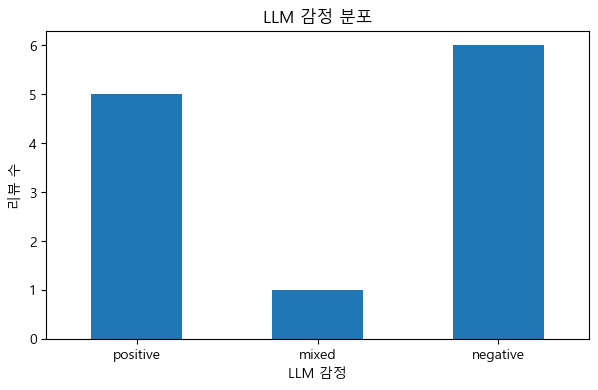

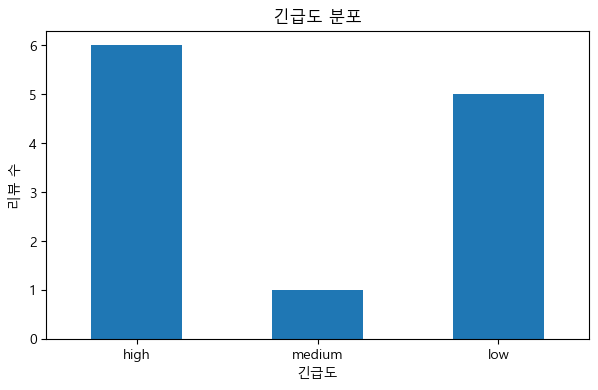

In [7]:
# ============================================================
# 4-1. 감정/긴급도 분포 시각화
# ============================================================

if "llm_sentiment" in df_game.columns:
    sentiment_counts = df_game["llm_sentiment"].value_counts().reindex(["positive", "mixed", "neutral", "negative"]).dropna()
    ax = sentiment_counts.plot(kind="bar", figsize=(7, 4))
    ax.set_title("LLM 감정 분포")
    ax.set_xlabel("LLM 감정")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()

if "urgency" in df_game.columns:
    urgency_counts = df_game["urgency"].value_counts().reindex(["high", "medium", "low"]).dropna()
    ax = urgency_counts.plot(kind="bar", figsize=(7, 4))
    ax.set_title("긴급도 분포")
    ax.set_xlabel("긴급도")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()


# 5. 기간별 반응 변화

출시 후 분석에서는 D0-D7, D8-D30처럼 기간별로 반응이 어떻게 달라지는지 보는 것이 중요합니다.

- D0-D7: 출시 직후 첫인상, 조작, 튜토리얼, 최적화 문제
- D8-D30: 어느 정도 플레이한 뒤의 반복성, 콘텐츠 밀도, 밸런스, 버그 문제


,release_period,review_count,steam_positive_rate,llm_positive_rate,llm_negative_mixed_rate,high_urgency_rate,avg_playtime_hours
0,D0-D7,6,0.333333,0.333333,0.666667,0.666667,30.250000
1,D8-D30,6,0.666667,0.500000,0.500000,0.333333,102.352778


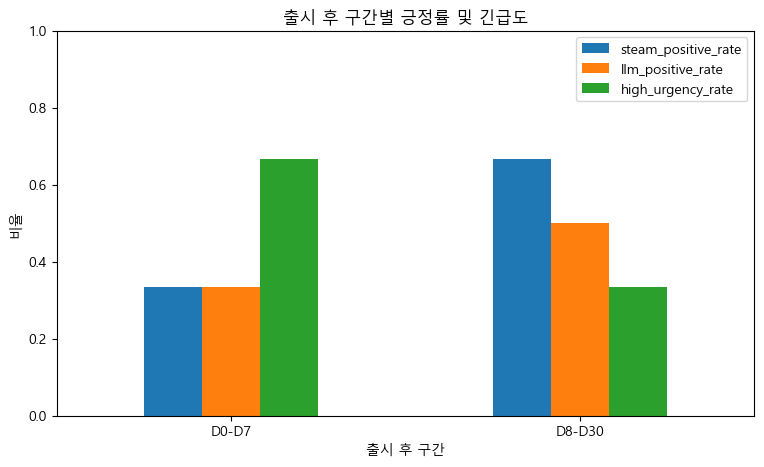

In [8]:
# ============================================================
# 5. 기간별 반응 변화
# ============================================================

period_summary = (
    df_game
    .groupby("release_period", dropna=False)
    .agg(
        review_count=("recommendationid", "count"),
        steam_positive_rate=("steam_label_text", lambda s: (s == "positive").mean()),
        llm_positive_rate=("llm_sentiment", lambda s: (s == "positive").mean()),
        llm_negative_mixed_rate=("llm_sentiment", lambda s: s.isin(["negative", "mixed"]).mean()),
        high_urgency_rate=("urgency", lambda s: (s == "high").mean()),
        avg_playtime_hours=("playtime_at_review_hours", "mean")
    )
    .reset_index()
)

display(period_summary)

# 그래프
if not period_summary.empty:
    plot_df = period_summary.set_index("release_period")[["steam_positive_rate", "llm_positive_rate", "high_urgency_rate"]]
    ax = plot_df.plot(kind="bar", figsize=(9, 5))
    ax.set_title("출시 후 구간별 긍정률 및 긴급도")
    ax.set_xlabel("출시 후 구간")
    ax.set_ylabel("비율")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.show()


,days_from_release,review_count,steam_positive_rate,high_urgency_rate
0,1,1,0.0,1.0
1,2,4,0.5,0.5
2,6,1,0.0,1.0
3,9,1,1.0,0.0
4,10,1,1.0,0.0
5,15,2,0.5,0.5
6,18,1,1.0,0.0
7,25,1,0.0,1.0


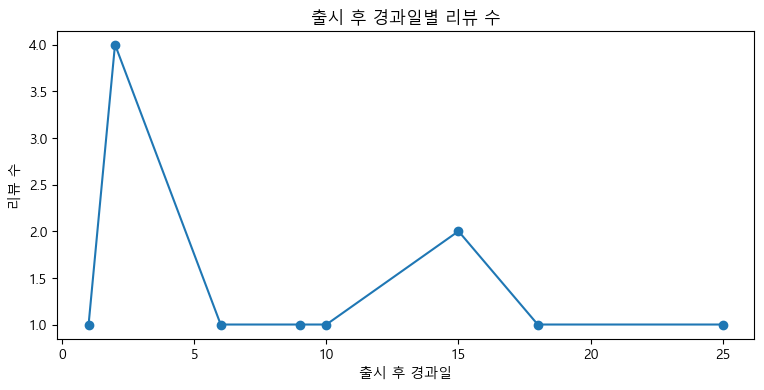

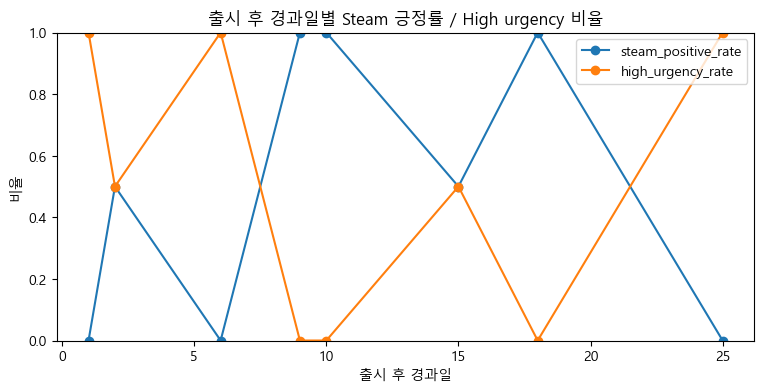

In [9]:
# ============================================================
# 5-1. 일자별 리뷰 수와 긍정률
# ============================================================

if "days_from_release" in df_game.columns:
    daily_summary = (
        df_game
        .dropna(subset=["days_from_release"])
        .assign(days_from_release=lambda d: d["days_from_release"].astype(int))
        .groupby("days_from_release")
        .agg(
            review_count=("recommendationid", "count"),
            steam_positive_rate=("steam_label_text", lambda s: (s == "positive").mean()),
            high_urgency_rate=("urgency", lambda s: (s == "high").mean())
        )
        .reset_index()
        .sort_values("days_from_release")
    )

    display(daily_summary)

    if not daily_summary.empty:
        ax = daily_summary.plot(x="days_from_release", y="review_count", kind="line", marker="o", figsize=(9, 4), legend=False)
        ax.set_title("출시 후 경과일별 리뷰 수")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("리뷰 수")
        plt.show()

        ax = daily_summary.plot(x="days_from_release", y=["steam_positive_rate", "high_urgency_rate"], kind="line", marker="o", figsize=(9, 4))
        ax.set_title("출시 후 경과일별 Steam 긍정률 / High urgency 비율")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("비율")
        plt.ylim(0, 1)
        plt.show()
else:
    display(Markdown("`days_from_release` 컬럼이 없어 일자별 분석을 생략합니다."))


# 6. Steam 라벨과 LLM 감정 비교

Steam의 추천/비추천 라벨은 유저의 최종 판단을 보여주지만, 리뷰 본문 안의 세부 불만까지 보여주지는 못합니다.

따라서 Steam 긍정 리뷰 안에서도 LLM이 `mixed` 또는 `negative`로 판단한 리뷰가 있는지 확인합니다.


In [10]:
# ============================================================
# 6. Steam 라벨과 LLM 감정 비교
# ============================================================

if {"steam_label_text", "llm_sentiment"}.issubset(df_game.columns):
    steam_llm_crosstab = pd.crosstab(
        df_game["steam_label_text"],
        df_game["llm_sentiment"],
        margins=True
    )
    display(steam_llm_crosstab)

    steam_positive_but_not_llm_positive = df_game[
        (df_game["steam_label_text"] == "positive") &
        (~df_game["llm_sentiment"].eq("positive"))
    ].copy()

    display(Markdown(f"""
## 긍정 리뷰 안의 개선 요구

Steam 기준 긍정 리뷰 중 LLM이 `positive`가 아닌 리뷰는 **{len(steam_positive_but_not_llm_positive)}개**입니다.

이 리뷰들은 게임을 추천하면서도 동시에 불편한 점이나 개선 요구를 포함할 가능성이 있습니다.
"""))

    display(
        steam_positive_but_not_llm_positive[
            [c for c in ["recommendationid", "review_datetime", "playtime_at_review_hours", "llm_sentiment", "primary_issue", "urgency", "summary", "suggested_action"] if c in steam_positive_but_not_llm_positive.columns]
        ].head(10)
    )
else:
    display(Markdown("Steam 라벨 또는 LLM 감정 컬럼이 없어 비교를 생략합니다."))


llm_sentiment,mixed,negative,positive,All
steam_label_text,,,,
negative,0,6,0,6
positive,1,0,5,6
All,1,6,5,12



## 긍정 리뷰 안의 개선 요구

Steam 기준 긍정 리뷰 중 LLM이 `positive`가 아닌 리뷰는 **1개**입니다.

이 리뷰들은 게임을 추천하면서도 동시에 불편한 점이나 개선 요구를 포함할 가능성이 있습니다.


,recommendationid,review_datetime,playtime_at_review_hours,llm_sentiment,primary_issue,urgency,summary,suggested_action
10,194267589,2025-05-05 05:12:22,390.883333,mixed,gameplay_loop,medium,"리뷰어는 전작에 이어 이번 작품도 스토리라인, 전투, 좀비 난이도 등 전반적으로 매우 즐겁다고 평가하며 95%의 높은 점수를 주었습니다. 하지만 스토리 모드의 약탈자 및 용병 시스템이 반복적이고 해결 방식이 ...",약탈자 및 용병 시스템의 밸런스를 재조정하여 플레이어가 합리적으로 대응할 수 있도록 개선. 약탈자 공격을 멈추는 방법에 대한 다양한 선택지 또는 명확한 해결책을 제공하여 반복적인 전투나 불합리한 해결 방식을 ...


# 7. 부정 이슈 분석

출시 후 운영 판단의 핵심은 **부정 리뷰가 어떤 문제를 반복해서 말하는지** 확인하는 것입니다.

여기서는 `llm_issue_tags_flat.csv`를 기준으로 부정 태그를 집계합니다.


,tag_category,negative_tag_count,affected_review_count,high_urgency_review_count,medium_urgency_review_count,avg_playtime_hours,votes_up_sum,representative_evidence,issue_name_kor
8,ui_ux,5,4,4,0,3.543333,89,"This game has nothin' [tutorial] / inventory management is abysmal, Why no option to drop stuff on the floor instead...",UI/UX
5,gameplay_loop,4,4,3,1,100.012500,85,"loot is oversimplified, stealth is absolute dog, economy is trash, weird design choices / fast moving zombies are no...",게임플레이 루프
3,control,3,3,3,0,4.455556,91,"movement and combat is just too clunky, Why can I not press shift again to stop running / Janky controls",조작감
4,difficulty,2,2,2,0,4.358333,8,"absolutely hard to get into it, no clue about whatsoever, game just throws you in, no idea of what to do / not enoug...",난이도
0,balance,2,2,1,1,195.941667,79,"Selling price of items is about 25% of the buying price, Wood weighs 9 kilo a piece and with a medium backpack you c...",밸런스
1,bug,1,1,1,0,160.150000,1,Saved games disapear suddenly,버그
2,content_volume,1,1,1,0,4.000000,1,Lacking basic content,콘텐츠 분량


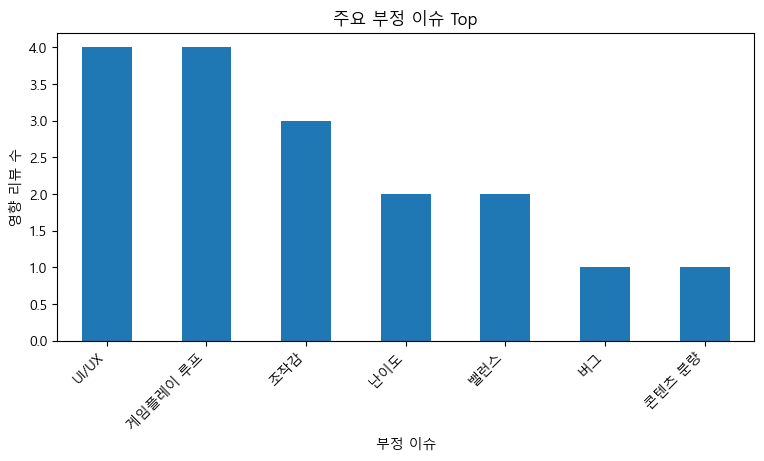

In [11]:
# ============================================================
# 7. 부정 이슈 분석
# ============================================================

ISSUE_NAME_KOR = {
    "positive_praise": "긍정 칭찬",
    "gameplay_loop": "게임플레이 루프",
    "content_volume": "콘텐츠 분량",
    "control": "조작감",
    "difficulty": "난이도",
    "multiplayer_network": "멀티/네트워크",
    "ui_ux": "UI/UX",
    "bug": "버그",
    "balance": "밸런스",
    "price_value": "가격/가치",
    "crash": "크래시",
    "performance": "성능",
    "other": "기타",
    "graphics_audio": "그래픽/사운드",
    "translation_localization": "번역/현지화",
    "developer_communication": "개발사 소통",
    "progression_grind": "성장/반복 노가다",
    "story": "스토리",
    "optimization": "최적화",
    "monetization": "과금/수익화",
    "save_progression": "저장/진행",
}

neg_tags = df_game_tags[df_game_tags["tag_sentiment"].eq("negative")].copy()

if neg_tags.empty:
    display(Markdown("부정 태그가 없습니다."))
    negative_issue_summary = pd.DataFrame()
else:
    negative_issue_summary = (
        neg_tags
        .groupby("tag_category")
        .agg(
            negative_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            high_urgency_review_count=("recommendationid", lambda x: neg_tags.loc[x.index].query("urgency == 'high'")["recommendationid"].nunique()),
            medium_urgency_review_count=("recommendationid", lambda x: neg_tags.loc[x.index].query("urgency == 'medium'")["recommendationid"].nunique()),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            votes_up_sum=("votes_up", "sum"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(2)))
        )
        .reset_index()
    )

    negative_issue_summary["issue_name_kor"] = negative_issue_summary["tag_category"].map(ISSUE_NAME_KOR).fillna(negative_issue_summary["tag_category"])
    negative_issue_summary = negative_issue_summary.sort_values(
        ["affected_review_count", "negative_tag_count", "high_urgency_review_count"],
        ascending=False
    )

    display(negative_issue_summary.head(TOP_N_ISSUES))

    ax = negative_issue_summary.head(TOP_N_ISSUES).set_index("issue_name_kor")["affected_review_count"].plot(kind="bar", figsize=(9, 4))
    ax.set_title("주요 부정 이슈 Top")
    ax.set_xlabel("부정 이슈")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 8. 플레이타임별 부정 원인

같은 부정 리뷰라도 플레이타임에 따라 의미가 다릅니다.

| 플레이타임 | 해석 |
|---|---|
| 0~1시간 | 첫인상, 조작, 튜토리얼, 최적화, 기대 불일치 문제 |
| 1~5시간 | 초반 재미, 콘텐츠 밀도, 난이도 문제 |
| 5시간 이상 | 반복성, 밸런스, 후반 콘텐츠, 업데이트 문제 |


tag_category,UI/UX,게임플레이 루프,조작감,밸런스,난이도,기타,버그
playtime_bin,,,,,,,
0~1시간,2,1,1,1,1,0,0
1~5시간,2,2,1,0,0,1,0
5시간 이상,1,1,1,1,1,0,1


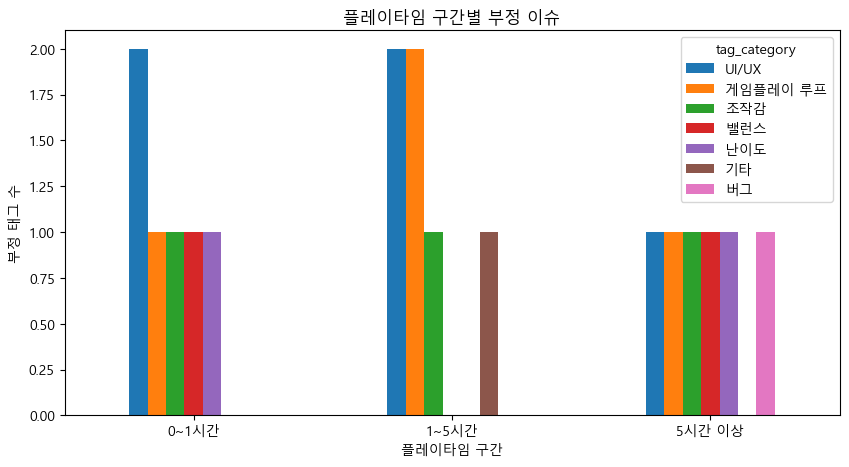

In [12]:
# ============================================================
# 8. 플레이타임별 부정 원인
# ============================================================

if neg_tags.empty:
    display(Markdown("부정 태그가 없어 플레이타임별 부정 원인 분석을 생략합니다."))
else:
    playtime_issue_table = pd.crosstab(
        neg_tags["playtime_bin"],
        neg_tags["tag_category"].map(ISSUE_NAME_KOR).fillna(neg_tags["tag_category"])
    )

    # 전체 빈도가 높은 이슈만 보기 좋게 정렬
    top_issue_cols = playtime_issue_table.sum(axis=0).sort_values(ascending=False).head(TOP_N_ISSUES).index
    playtime_issue_table = playtime_issue_table[top_issue_cols]

    display(playtime_issue_table)

    ax = playtime_issue_table.plot(kind="bar", figsize=(10, 5))
    ax.set_title("플레이타임 구간별 부정 이슈")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("부정 태그 수")
    plt.xticks(rotation=0)
    plt.show()


# 9. 패치·운영 우선순위 산정
!!!!!!!!!!!!!!!!!!!!!!!!임의 설정값임!!!!!!!!!!!!!!!!!!!!!!!!
출시 후 분석의 최종 결과는 **무엇을 먼저 대응할 것인가**입니다.\
여기서는 간단한 점수 기준으로 이슈별 우선순위를 계산합니다.

## 점수 기준
!!!!!!!!!!!!!!!!!!!!!!!!임의 설정값임!!!!!!!!!!!!!!!!!!!!!!!!   
!!!!!!!!!!!!!!!!!!!!!!!!테스트 용임!!!!!!!!!!!!!!!!!!!!!!!! 
!!!!!!!!!!!!!!!!!!!!!!!!이렇게 안할꺼임!!!!!!!!!!!!!!!!!!!!!!!! 
!!!!!!!!!!!!!!!!!!!!!!!!넣는거 확정 아님!!!!!!!!!!!!!!!!!!!!!!!!    
`패치 우선순위 점수 = 영향 리뷰 수 + high 긴급도 리뷰 수 × 1.5 + 0~1시간 이탈 리뷰 수 × 0.7 + log(유용함 투표 수 + 1) × 0.2`

해석은 다음과 같습니다.

- 영향 리뷰 수가 많을수록 우선순위가 높음
- high urgency가 많을수록 우선순위가 높음
- 0~1시간 부정 리뷰에서 나온 문제는 초기 이탈 위험이 있으므로 가중
- votes_up이 높은 리뷰의 문제는 다른 유저도 공감했을 가능성이 있으므로 소폭 반영

이 점수는 절대적인 정답이 아니라, 패치 회의에서 우선순위를 정하기 위한 **보조 기준**입니다.


,issue_name_kor,action_type,patch_priority_score,affected_review_count,high_urgency_review_count,short_exit_review_count,avg_playtime_hours,votes_up_sum,representative_evidence
8,UI/UX,2순위: 초기 이탈 방지,12.299962,4,4,2,3.543333,89,"This game has nothin' [tutorial] / inventory management is abysmal, Why no option to drop stuff on the floor instead..."
5,게임플레이 루프,2순위: 핵심 경험 개선,10.090869,4,3,1,100.012500,85,"loot is oversimplified, stealth is absolute dog, economy is trash, weird design choices / fast moving zombies are no..."
3,조작감,2순위: 초기 이탈 방지,9.104358,3,3,1,4.455556,91,"movement and combat is just too clunky, Why can I not press shift again to stop running / Janky controls"
4,난이도,2순위: 초기 이탈 방지,6.139445,2,2,1,4.358333,8,"absolutely hard to get into it, no clue about whatsoever, game just throws you in, no idea of what to do / not enoug..."
0,밸런스,2순위: 핵심 경험 개선,5.076405,2,1,1,195.941667,79,"Selling price of items is about 25% of the buying price, Wood weighs 9 kilo a piece and with a medium backpack you c..."
6,기타,4순위: 모니터링,2.858352,1,1,0,4.166667,5,not worth it
2,콘텐츠 분량,4순위: 모니터링,2.638629,1,1,0,4.000000,1,Lacking basic content


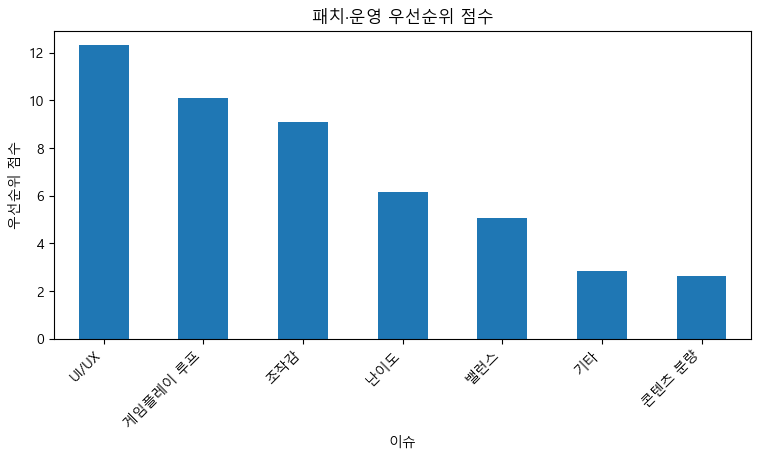

In [13]:
# ============================================================
# 9. 패치·운영 우선순위 산정
# ============================================================

def classify_action_type(row):
    issue = row["tag_category"]
    high = row["high_urgency_review_count"]
    short_exit = row["short_exit_review_count"]
    avg_playtime = row["avg_playtime_hours"]

    # 치명적 오류 계열
    if issue in ["bug", "crash", "performance", "optimization"] and high >= 1:
        return "1순위: 긴급 수정"

    # 초반 이탈 계열
    if issue in ["ui_ux", "control", "difficulty", "translation_localization"] and short_exit >= 1:
        return "2순위: 초기 이탈 방지"

    # 플레이 경험 핵심 계열
    if issue in ["gameplay_loop", "balance", "price_value"] and high >= 1:
        return "2순위: 핵심 경험 개선"

    # 오래 플레이한 유저의 누적 불만
    if pd.notna(avg_playtime) and avg_playtime >= 5:
        return "3순위: 유지 경험 개선"

    return "4순위: 모니터링"

if neg_tags.empty:
    display(Markdown("부정 태그가 없어 패치 우선순위 산정을 생략합니다."))
    patch_priority = pd.DataFrame()
else:
    short_exit_ids = set(
        neg_tags.loc[neg_tags["playtime_bin"].eq("0~1시간"), "recommendationid"].dropna().astype(str)
    )

    patch_priority = (
        neg_tags
        .groupby("tag_category")
        .agg(
            negative_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            high_urgency_review_count=("recommendationid", lambda x: neg_tags.loc[x.index].query("urgency == 'high'")["recommendationid"].nunique()),
            medium_urgency_review_count=("recommendationid", lambda x: neg_tags.loc[x.index].query("urgency == 'medium'")["recommendationid"].nunique()),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            votes_up_sum=("votes_up", "sum"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(2)))
        )
        .reset_index()
    )

    patch_priority["short_exit_review_count"] = patch_priority["tag_category"].apply(
        lambda issue: neg_tags.loc[
            (neg_tags["tag_category"] == issue) &
            (neg_tags["recommendationid"].astype(str).isin(short_exit_ids)),
            "recommendationid"
        ].nunique()
    )

    patch_priority["patch_priority_score"] = (
        patch_priority["affected_review_count"]
        + patch_priority["high_urgency_review_count"] * 1.5
        + patch_priority["short_exit_review_count"] * 0.7
        + np.log1p(patch_priority["votes_up_sum"].fillna(0)) * 0.2
    )

    patch_priority["issue_name_kor"] = patch_priority["tag_category"].map(ISSUE_NAME_KOR).fillna(patch_priority["tag_category"])
    patch_priority["action_type"] = patch_priority.apply(classify_action_type, axis=1)

    patch_priority = patch_priority.sort_values("patch_priority_score", ascending=False)

    display(
        patch_priority[[
            "issue_name_kor",
            "action_type",
            "patch_priority_score",
            "affected_review_count",
            "high_urgency_review_count",
            "short_exit_review_count",
            "avg_playtime_hours",
            "votes_up_sum",
            "representative_evidence"
        ]].head(TOP_N_ISSUES)
    )

    ax = patch_priority.head(TOP_N_ISSUES).set_index("issue_name_kor")["patch_priority_score"].plot(kind="bar", figsize=(9, 4))
    ax.set_title("패치·운영 우선순위 점수")
    ax.set_xlabel("이슈")
    ax.set_ylabel("우선순위 점수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 10. 긍정 강점 분석

출시 후 운영은 문제 수정만이 아니라, 유저가 좋아한 강점을 유지하고 강화하는 것도 중요합니다.

여기서는 긍정 태그를 기준으로 현재 게임의 강점을 확인합니다.


,tag_category,positive_tag_count,affected_review_count,avg_playtime_hours,representative_evidence,issue_name_kor
6,positive_praise,6,6,102.930556,"If you liked any or all 3 of those you will probably have some fun here, each time I became 10x better and faster, n...",긍정 칭찬
4,gameplay_loop,3,3,72.850000,"normal character control where you are in 3rd person, or you can do like a tactical mode / open-world design offers ...",게임플레이 루프
3,developer_communication,2,2,37.191667,"The Dev is still updating, recently an experimental branch that stop constitution from dropping over time / the auth...",개발사 소통
0,balance,1,1,71.333333,stop constitution from dropping over time (max health) which thank God because that ♥♥♥♥ was annoying to juggle,밸런스
1,bug,1,1,38.333333,haven't encountered any memorable bugs,버그
2,content_volume,1,1,390.883333,"sandbox now, it is by far way better than the storymode",콘텐츠 분량
5,other,1,1,108.883333,relationship mechanics are another highlight,기타


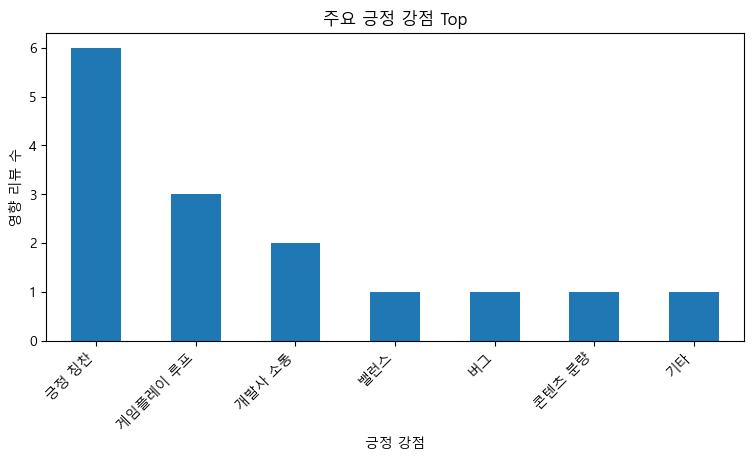

In [14]:
# ============================================================
# 10. 긍정 강점 분석
# ============================================================

pos_tags = df_game_tags[df_game_tags["tag_sentiment"].eq("positive")].copy()

if pos_tags.empty:
    display(Markdown("긍정 태그가 없습니다."))
    positive_strength_summary = pd.DataFrame()
else:
    positive_strength_summary = (
        pos_tags
        .groupby("tag_category")
        .agg(
            positive_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3)))
        )
        .reset_index()
    )

    positive_strength_summary["issue_name_kor"] = positive_strength_summary["tag_category"].map(ISSUE_NAME_KOR).fillna(positive_strength_summary["tag_category"])
    positive_strength_summary = positive_strength_summary.sort_values(
        ["affected_review_count", "positive_tag_count"],
        ascending=False
    )

    display(positive_strength_summary.head(TOP_N_ISSUES))

    ax = positive_strength_summary.head(TOP_N_ISSUES).set_index("issue_name_kor")["affected_review_count"].plot(kind="bar", figsize=(9, 4))
    ax.set_title("주요 긍정 강점 Top")
    ax.set_xlabel("긍정 강점")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 11. 보고서

분석 대상 게임은 Survivalist: Invisible Strain이며, 총 12개의 LLM 분석 리뷰를 기준으로 출시 후 반응을 확인하였다.

Steam 기준 긍정률은 50.0%, LLM 기준 긍정률은 **41.7%**로 나타났다.  
LLM 기준 부정 또는 혼합 감정 리뷰 비율은 58.3%, High urgency 리뷰 비율은 **50.0%**이다. 

기간별로 보면 **D0-D7 구간은 리뷰 6개, Steam 긍정률 33.3%, High urgency 비율 66.7% / D8-D30 구간은 리뷰 6개, Steam 긍정률 66.7%, High urgency 비율 33.3%**이다. 

부정 리뷰에서 우선적으로 확인된 이슈는 UI/UX, 게임플레이 루프, 조작감이다.  
이 이슈들은 리뷰 본문에서 반복적으로 나타난 불만 요소이며, 패치 또는 운영 대응 시 우선 검토할 필요가 있다.  

반대로 긍정 리뷰에서 확인된 주요 강점은 긍정 칭찬, 게임플레이 루프, 개발사 소통이다.    
출시 후 운영에서는 부정 이슈를 수정하는 동시에, 유저가 긍정적으로 평가한 강점을 유지하고 확장하는 방향도 함께 고려해야 한다.

따라서 본 게임의 출시 후 운영 판단은 단순 긍정률만 보는 것이 아니라,    
기간별 반응 변화, 플레이타임별 불만 원인, 반복 부정 이슈, 긍정 강점을 함께 확인하는 방식으로 진행하는 것이 적절하다.